In [1]:
import h5py 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
Fs = 5000
ms_to_samples = lambda x: int(x / 1000 * Fs)

In [3]:
from scipy.signal import iirnotch, tf2sos, butter, sosfilt, sosfilt_zi

ONLINE_THRESHOLD = 7.000000000000001e-09


def calculate_tkeo(x):
    x = np.asarray(x)
    tkeo = np.zeros_like(x)
    tkeo[1:-1] = x[1:-1]**2 - x[:-2] * x[2:]
    tkeo[0] = tkeo[1]
    tkeo[-1] = tkeo[-2]
    return tkeo


def make_online_filters(fs=5000):
    """Create the same SOS filters and initial states as DataProcessor.create_filters()."""
    notch_fr = 50
    notch_width = 1
    Q = notch_fr / notch_width
    b_notch, a_notch = iirnotch(notch_fr, Q, fs=fs)
    sos_notch = tf2sos(b_notch, a_notch)
    zi_notch = sosfilt_zi(sos_notch)

    sos_butter = butter(
        N=4,
        Wn=[5, 90],
        btype="bandpass",
        output="sos",
        fs=fs,
    )
    zi_butter = sosfilt_zi(sos_butter)
    return sos_notch, zi_notch, sos_butter, zi_butter


def online_like_filter_by_blocks(emg_raw, block_samples=None, fs=5000, use_tkeo=False):
    """
    Repeat online filtering as closely as possible:
    - process signal block-by-block, like incoming Resonance packs;
    - keep SOS filter state `zi` between blocks;
    - notch 50 Hz first, then Butterworth 5-90 Hz;
    - if use_tkeo=True, apply TKEO after filtering;
    - multiply by 1e3 before online detection/plotting.
    """
    emg_raw = np.asarray(emg_raw, dtype=float)
    if block_samples is None:
        block_samples = [len(emg_raw)]

    sos_notch, zi_notch, sos_butter, zi_butter = make_online_filters(fs=fs)

    chunks = []
    start = 0
    for n_samples in np.asarray(block_samples, dtype=int):
        stop = start + int(n_samples)
        if stop <= start:
            continue
        chunk = emg_raw[start:stop]
        if len(chunk) == 0:
            break

        chunk, zi_notch = sosfilt(sos_notch, chunk, axis=0, zi=zi_notch)
        chunk, zi_butter = sosfilt(sos_butter, chunk, axis=0, zi=zi_butter)
        chunks.append(chunk)
        start = stop

        if start >= len(emg_raw):
            break

    if start < len(emg_raw):
        chunk = emg_raw[start:]
        chunk, zi_notch = sosfilt(sos_notch, chunk, axis=0, zi=zi_notch)
        chunk, zi_butter = sosfilt(sos_butter, chunk, axis=0, zi=zi_butter)
        chunks.append(chunk)

    emg_f = np.concatenate(chunks) if chunks else np.asarray([], dtype=float)
    if use_tkeo:
        return calculate_tkeo(emg_f) * 1e3
    return emg_f * 1e3


def find_trigger_onsets_by_blocks(ttl, block_samples=None, bit=4):
    """Match DataProcessor._process_trigger(): np.diff is evaluated inside each incoming pack."""
    ttl = np.asarray(ttl, dtype=np.uint8)
    if block_samples is None:
        block_samples = [len(ttl)]

    trigger = ((ttl >> bit) & 0b1).astype(int)
    onsets = []
    start = 0
    for n_samples in np.asarray(block_samples, dtype=int):
        stop = start + int(n_samples)
        if stop <= start:
            continue
        tr_chunk = trigger[start:stop]
        events = np.where(np.diff(tr_chunk) == 1)[0]
        onsets.extend(start + events + 1)
        start = stop
        if start >= len(trigger):
            break

    if start < len(trigger):
        tr_chunk = trigger[start:]
        events = np.where(np.diff(tr_chunk) == 1)[0]
        onsets.extend(start + events + 1)

    return trigger, np.asarray(onsets, dtype=int)


In [6]:
subject = "03AZ"
record = "03_03AZ_fb"
filename = os.path.join(r"..\data", subject, record + ".hdf")
# filename = r"C:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\PonkSync-Trainer\data\03AZ\02_03AZ_fb.hdf"
with h5py.File(filename, "r") as h5f:
    print(h5f["eeg"].keys())
    data = h5f["eeg/data"][:]
    block_samples = h5f["eeg/blocks"]["samples"][:]

# Online settings: ProcessingSettings.montage == 1, emg_channels_monopolar == 1.
emg_raw = data[:, 0]
ttl = data[:, -1].astype(np.uint8)

emg_filtered = online_like_filter_by_blocks(emg_raw, block_samples, fs=Fs, use_tkeo=False)
emg_tkeo = online_like_filter_by_blocks(emg_raw, block_samples, fs=Fs, use_tkeo=True)

print("data:", data.shape)
print("blocks:", len(block_samples), "sum samples:", int(np.sum(block_samples)))
print("emg_filtered:", emg_filtered.shape, "emg_tkeo:", emg_tkeo.shape)
print("TKEO range:", np.nanmin(emg_tkeo), np.nanmax(emg_tkeo))
print("threshold:", ONLINE_THRESHOLD)


<KeysViewHDF5 ['blocks', 'data', 'streamInfo']>
data: (1157881, 3)
blocks: 2464 sum samples: 1157880
emg_filtered: (1157881,) emg_tkeo: (1157881,)
TKEO range: -0.0654801279859063 1.975491845983668
threshold: 7.000000000000001e-09


In [7]:
df_online = pd.read_csv(os.path.join(r"..\data", subject, record + ".csv"))
online_delays = df_online["error"].values

In [8]:
bit = 4
trigger, trigger_onsets = find_trigger_onsets_by_blocks(ttl, block_samples, bit=bit)
print("n trigger onsets:", len(trigger_onsets))
print(trigger_onsets)


n trigger onsets: 40
[   8741   37495   66730   95609  123994  153013  182078  210912  239607
  268146  297221  326685  356040  385079  414479  443678  472763  501427
  530887  559951  588711  617800  647005  675735  704534  733834  763118
  791723  820632  849057  877751  906795  936155  965315  993539 1022434
 1051063 1079832 1108677 1137526]


In [9]:
epoch_ms = (-1000, 1000)
emg = emg_tkeo

pre_samp = ms_to_samples(epoch_ms[0])
post_samp = ms_to_samples(epoch_ms[1])

emg_epochs = []
trigger_epochs = []
valid_onsets = []

for onset in trigger_onsets:
    start = onset + pre_samp
    stop = onset + post_samp

    if start < 0 or stop > len(emg):
        continue

    emg_epochs.append(emg[start:stop])
    trigger_epochs.append(trigger[start:stop])
    valid_onsets.append(onset)

emg_epochs = np.asarray(emg_epochs)
trigger_epochs = np.asarray(trigger_epochs)
valid_onsets = np.asarray(valid_onsets)
time_ms = np.arange(pre_samp, post_samp) / Fs * 1000

print(emg_epochs.shape)      # n_epochs x n_samples
print(trigger_epochs.shape)  # n_epochs x n_samples


(40, 10000)
(40, 10000)


In [10]:
def get_delays_from_signal(
    detection_signal,
    trigger_onsets,
    fs=5000,
    window_ms=(-500, 375),
    threshold=ONLINE_THRESHOLD,
):
    """Repeat online delay detection from DataProcessor.process_ponk()."""
    pre = int(window_ms[0] / 1000 * fs)
    post = int(window_ms[1] / 1000 * fs)

    delays_ms = []
    peak_samples = []
    valid_trigger_samples = []
    amplitudes = []
    n_crossings = []

    for trig_sample in trigger_onsets:
        start = trig_sample + pre
        stop = trig_sample + post

        if start < 0 or stop > len(detection_signal):
            continue

        x = detection_signal[start:stop]
        crossings = np.where(x > threshold)[0]

        if len(crossings) == 0:
            delays_ms.append(np.nan)
            peak_samples.append(np.nan)
            amplitudes.append(np.nan)
            n_crossings.append(0)
        else:
            onset_local = crossings[0]
            peak_sample = start + onset_local
            delay_ms = (peak_sample - trig_sample) / fs * 1000

            delays_ms.append(delay_ms)
            peak_samples.append(peak_sample)
            amplitudes.append(np.max(x[crossings]))
            n_crossings.append(len(crossings))

        valid_trigger_samples.append(trig_sample)

    return {
        "delays_ms": np.asarray(delays_ms, dtype=float),
        "trigger_samples": np.asarray(valid_trigger_samples, dtype=int),
        "peak_samples": np.asarray(peak_samples, dtype=float),
        "amplitudes": np.asarray(amplitudes, dtype=float),
        "n_crossings": np.asarray(n_crossings, dtype=int),
        "threshold": threshold,
        "detection_signal": detection_signal,
        "trigger": trigger,
    }


In [11]:
result = get_delays_from_signal(
    emg_tkeo,
    trigger_onsets,
    fs=Fs,
    window_ms=(-500, 375),
    threshold=ONLINE_THRESHOLD,
)


In [15]:
delays = result["delays_ms"]
summary = pd.DataFrame({
    "trial": np.arange(len(delays)),
    "trigger_sample": result["trigger_samples"],
    "delay_ms": delays,
    "peak_sample": result["peak_samples"],
    "amplitude": result["amplitudes"],
    "n_crossings": result["n_crossings"],
    "delay_online": online_delays
})
summary.head()


,trial,trigger_sample,delay_ms,peak_sample,amplitude,n_crossings,delay_online
0,0,8741,-500.0,6241.0,5.998937e-07,3558,-51.0
1,1,37495,-23.6,37377.0,3.708616e-08,212,-24.0
2,2,66730,-29.8,66581.0,5.437998e-08,98,-30.0
3,3,95609,-9.8,95560.0,2.892273e-08,133,-11.0
4,4,123994,-101.8,123485.0,9.257194e-09,66,-102.0


In [22]:
summary[["delay_ms", "delay_online"]].diff(axis=1).mean()

delay_ms        NaN
delay_online    8.4
dtype: float64

In [13]:
print("delays_ms:", delays)
print("mean:", np.nanmean(delays), "ms")
print("threshold:", result["threshold"])

delays_ms: [-5.000e+02 -2.360e+01 -2.980e+01 -9.800e+00 -1.018e+02        nan
 -1.500e+02  4.820e+01  4.620e+01 -2.620e+01 -1.858e+02 -1.318e+02
  2.000e-01  5.700e+01  4.520e+01 -2.780e+01  2.760e+01 -9.180e+01
 -8.180e+01 -5.580e+01 -5.400e+01 -1.348e+02 -1.630e+02 -1.120e+02
  8.740e+01 -1.336e+02 -5.300e+01 -1.548e+02 -2.882e+02 -1.390e+02
 -7.720e+01  4.380e+01  1.560e+01 -3.520e+01 -2.200e+00 -4.000e+00
  4.860e+01        nan        nan -7.160e+01]
mean: -65.37297297297297 ms
threshold: 7.000000000000001e-09


(<Figure size 1400x500 with 2 Axes>,
 <Axes: title={'center': '03AZ / 03_03AZ_fb: trial 1, delay = -23.6 ms, online_delay = -24.0 ms'}, xlabel='time from trigger, ms', ylabel='online detection signal'>)

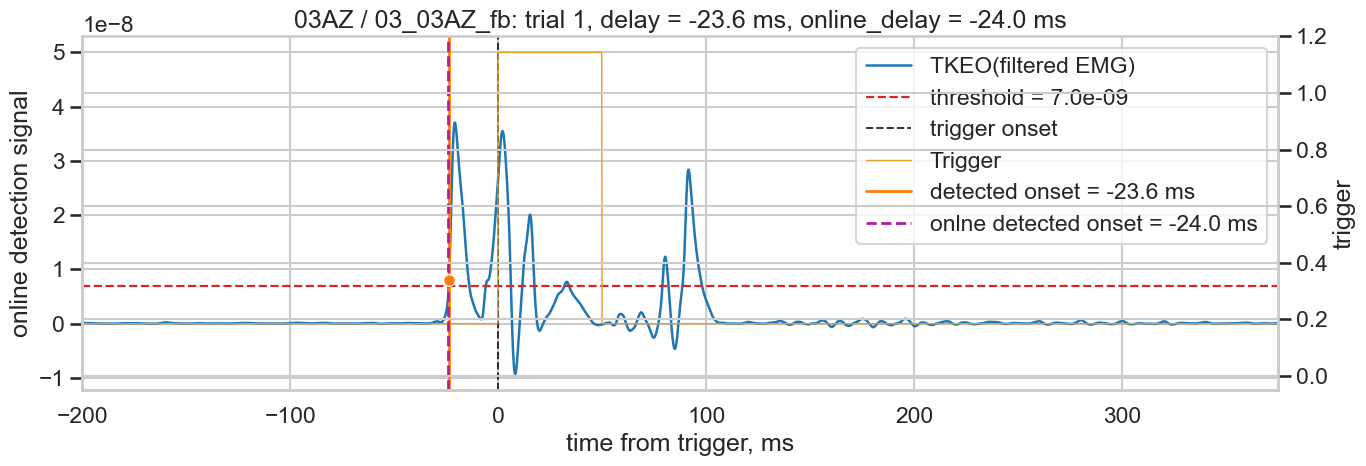

In [27]:
sns.set_theme(style="whitegrid", context="talk")


def plot_epoch_detection(n_epoch=1, xlim=(-200, 375)):
    threshold = result["threshold"]
    delay = result["delays_ms"][n_epoch]
    trig_sample = result["trigger_samples"][n_epoch]
    peak_sample = result["peak_samples"][n_epoch]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(time_ms, emg_epochs[n_epoch], lw=1.8, color="#1f77b4", label="TKEO(filtered EMG)")
    ax.axhline(threshold, color="#d62728", ls="--", lw=1.6, label=f"threshold = {threshold:.1e}")
    ax.axvline(0, color="black", ls="--", lw=1.4, alpha=0.8, label="trigger onset")

    ax.plot(time_ms, trigger_epochs[n_epoch]*1e-8*5, lw=1, color="#E59D29", label="Trigger")

    if np.isfinite(delay):
        onset_epoch_idx = int(peak_sample - (trig_sample + pre_samp))
        ax.axvline(delay, color="#ff7f0e", lw=2.0, label=f"detected onset = {delay:.1f} ms")
        ax.scatter(
            time_ms[onset_epoch_idx],
            emg_epochs[n_epoch, onset_epoch_idx],
            s=70,
            color="#ff7f0e",
            edgecolor="white",
            linewidth=0.8,
            zorder=5,
        )
    
    online_onset = summary["delay_online"][n_epoch]
    if np.isfinite(online_onset):
        onset_epoch_idx = int(peak_sample - (trig_sample + pre_samp))
        ax.axvline(online_onset, color="#b919a4", ls="--", lw=2.0, label=f"onlne detected onset = {online_onset:.1f} ms")

    ax2 = ax.twinx()
    # ax2.plot(time_ms, trigger_epochs[n_epoch], color="0.35", alpha=0.35, lw=1.4, label="trigger bit 4")
    ax2.set_ylim(-0.05, 1.2)
    ax2.set_ylabel("trigger")

    ax.set_xlim(*xlim)
    ax.set_xlabel("time from trigger, ms")
    ax.set_ylabel("online detection signal")
    ax.set_title(f"{subject} / {record}: trial {n_epoch}, delay = {delay:.1f} ms, online_delay = {online_onset:.1f} ms")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True)
    sns.despine(ax=ax, right=False)
    plt.tight_layout()

    return fig, ax

plot_epoch_detection(1)


(<Figure size 1400x500 with 2 Axes>,
 <Axes: title={'center': '03AZ / 03_03AZ_fb: trial 3, delay = -9.8 ms, online_delay = -11.0 ms'}, xlabel='time from trigger, ms', ylabel='online detection signal'>)

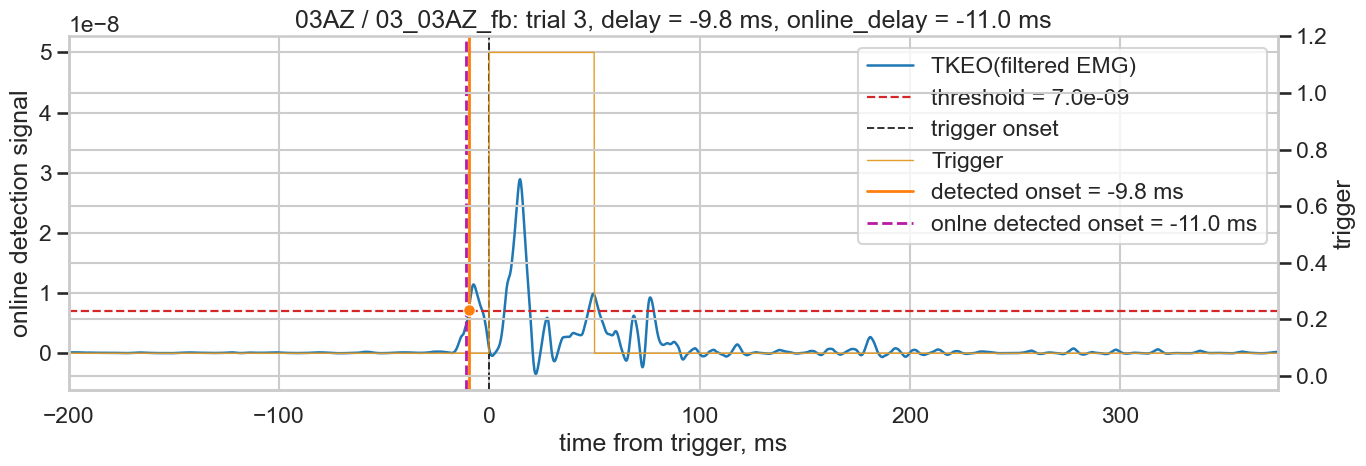

In [29]:
plot_epoch_detection(3)

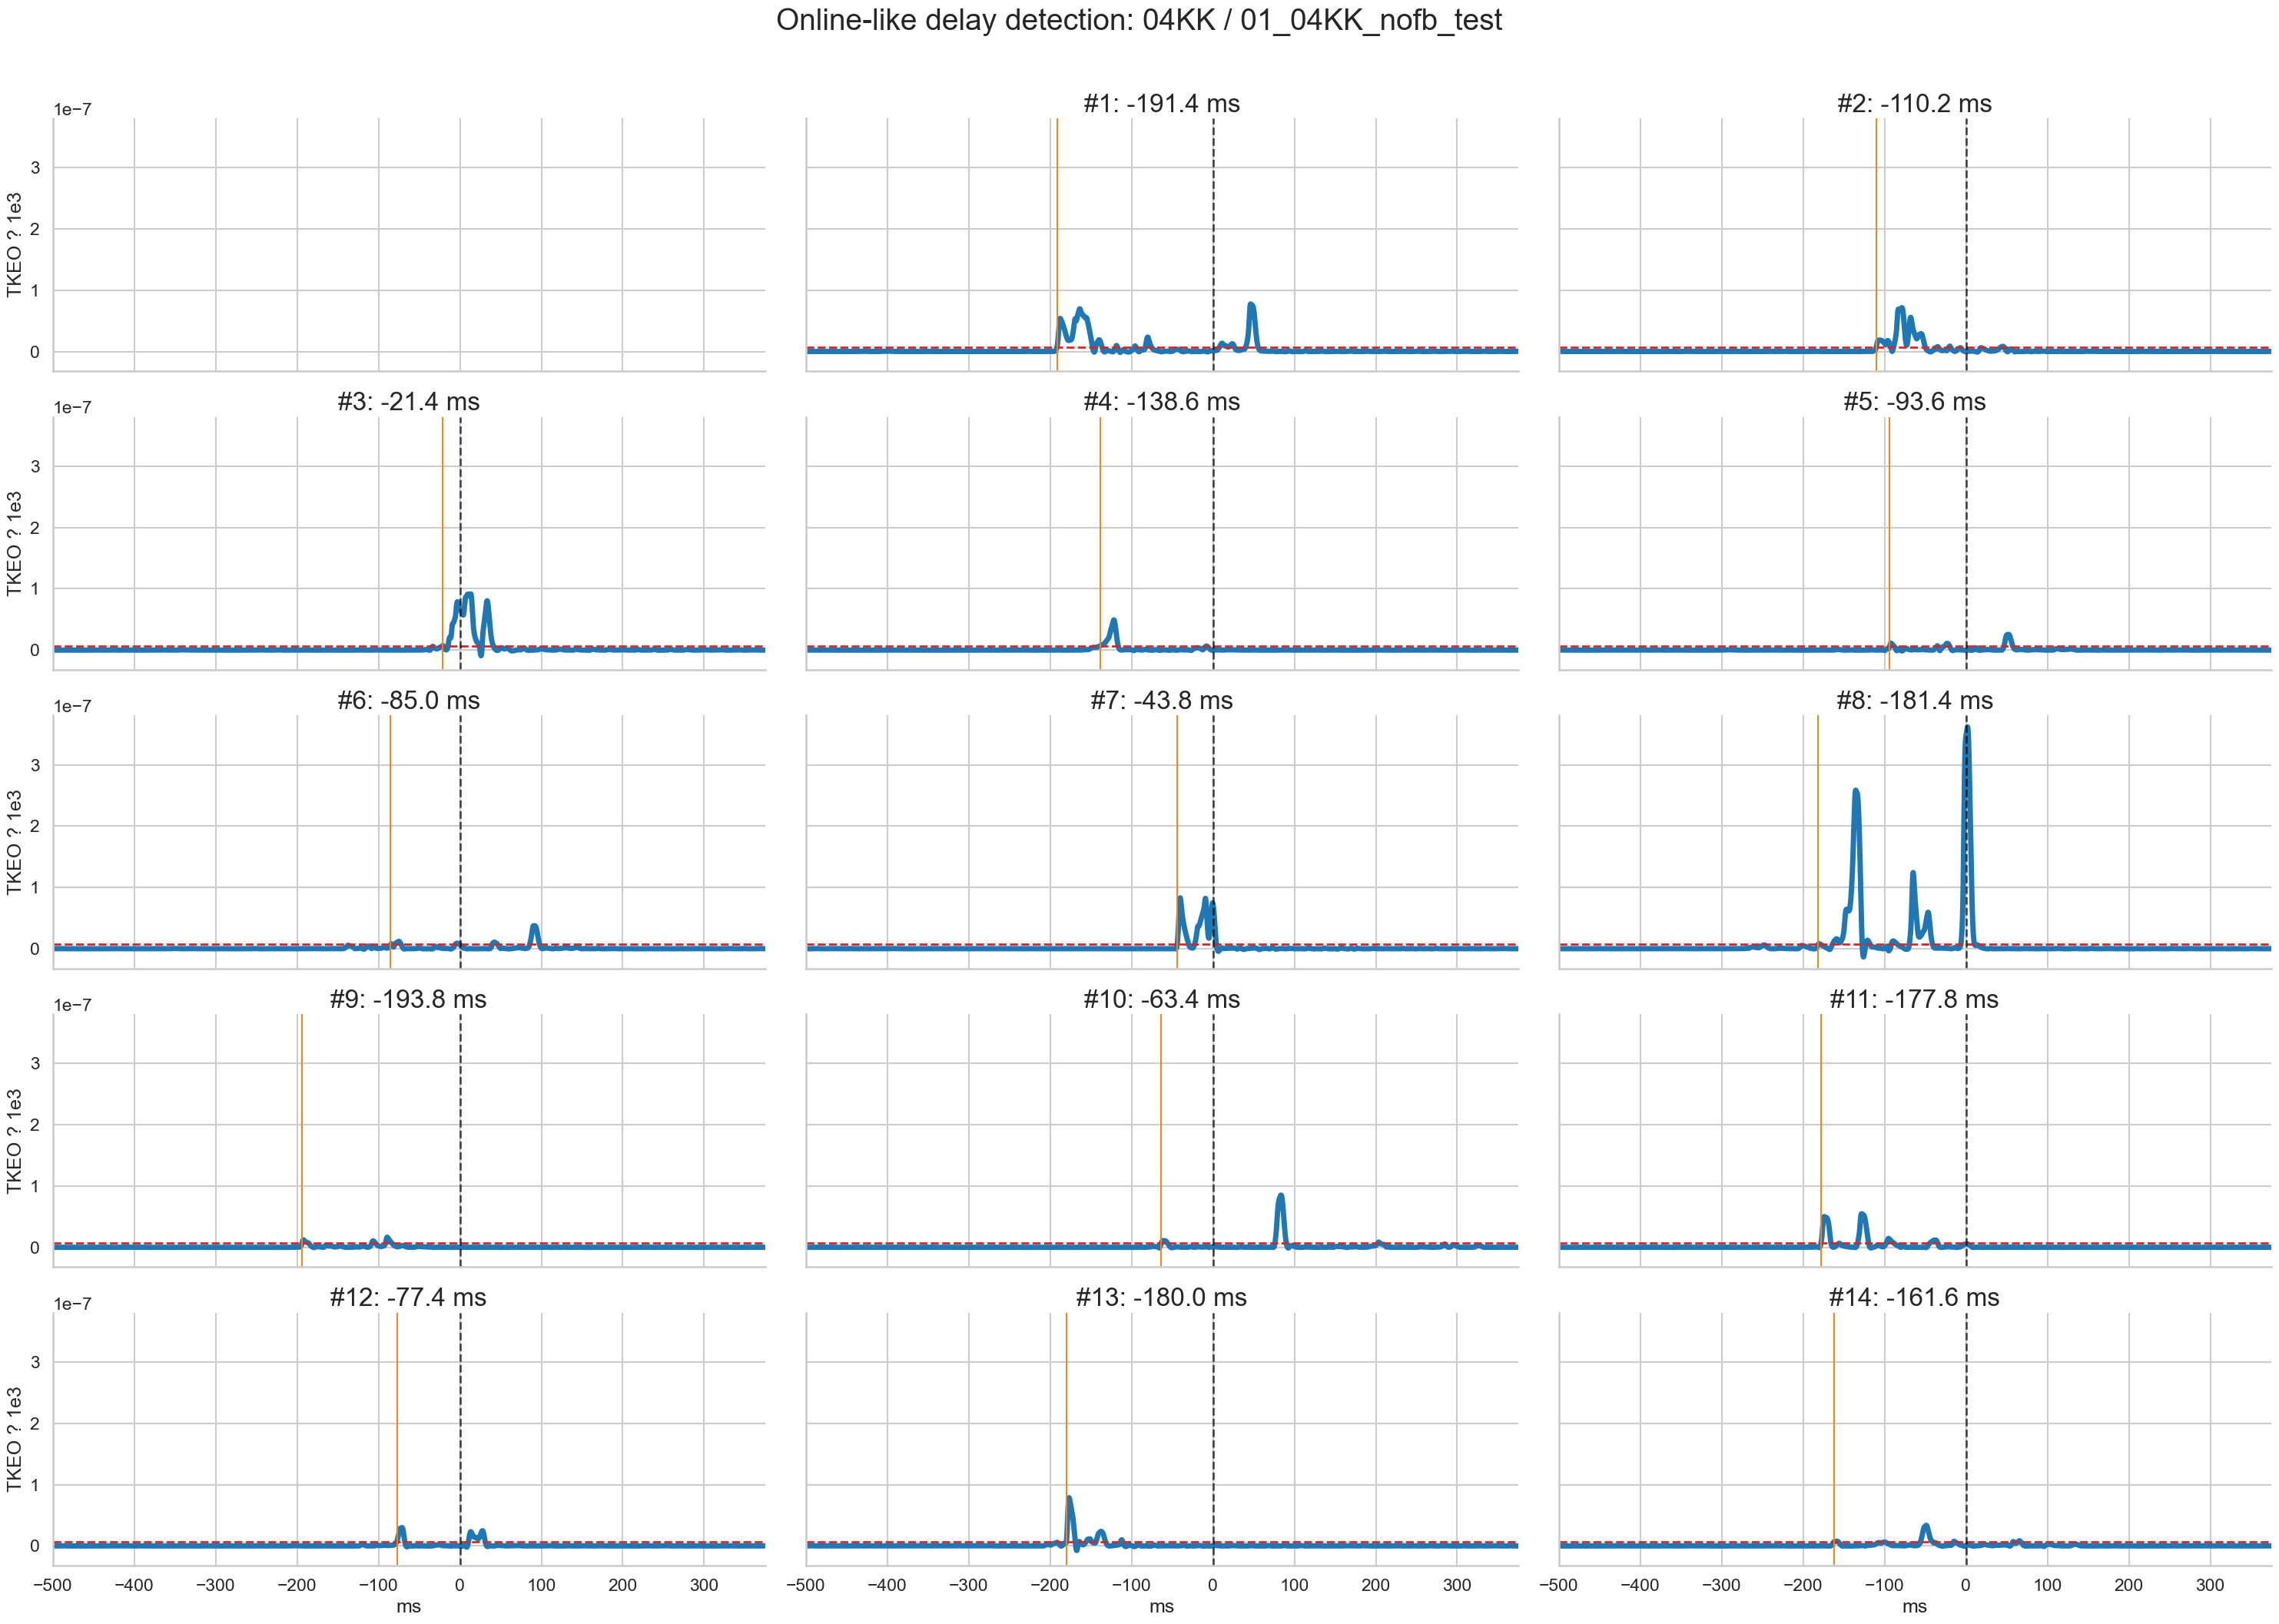

In [130]:
# Small multiples: every epoch in the same coordinate system as online delay detection.
n_cols = 3
n_rows = int(np.ceil(len(emg_epochs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 4.2 * n_rows), sharex=True, sharey=True)
axes = np.ravel(axes)
threshold = result["threshold"]

for i, ax in enumerate(axes):
    if i >= len(emg_epochs):
        ax.axis("off")
        continue
    if i== 0:
        continue

    ax.plot(time_ms, emg_epochs[i], color="#1f77b4", lw=5.0)
    ax.axhline(threshold, color="#d62728", ls="--", lw=2.0)
    ax.axvline(0, color="black", ls="--", lw=1.9, alpha=0.7)

    delay = result["delays_ms"][i]
    if np.isfinite(delay):
        ax.axvline(delay, color="#ff7f0e", lw=1.4)

    ax.set_xlim(-500, 375)
    ax.set_title(f"#{i}: {delay:.1f} ms" if np.isfinite(delay) else f"#{i}: no crossing", fontsize=24)

for ax in axes[-n_cols:]:
    ax.set_xlabel("ms")
for ax in axes[::n_cols]:
    ax.set_ylabel("TKEO ? 1e3")

fig.suptitle(f"Online-like delay detection: {subject} / {record}", y=1.01, fontsize=28)
sns.despine(fig=fig)
plt.tight_layout()


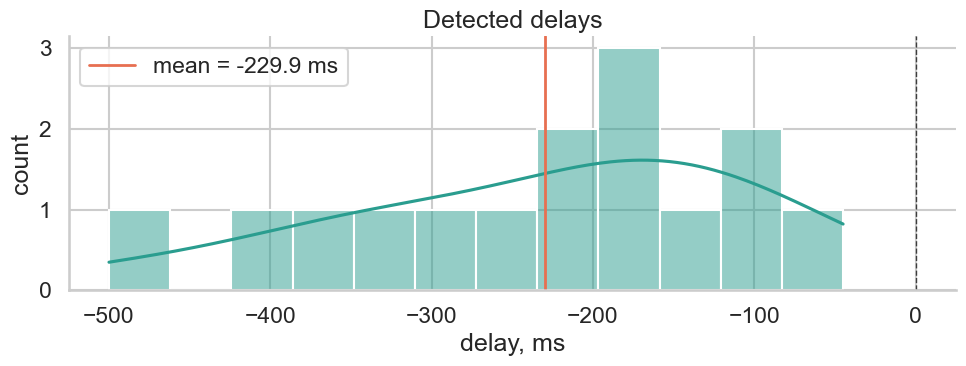

In [85]:
# Delay distribution.
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(delays, bins=12, kde=True, ax=ax, color="#2a9d8f")
ax.axvline(np.nanmean(delays), color="#e76f51", lw=2, label=f"mean = {np.nanmean(delays):.1f} ms")
ax.axvline(0, color="black", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("delay, ms")
ax.set_ylabel("count")
ax.set_title("Detected delays")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
